# **Carregando dados**

In [1]:
df <- read.csv("df_final.csv")

In [2]:
head(df)

,data_hora,vento_u,vento_v,periodo_onda_pico,pressao_media_mar,direcao_media_onda,coef_arrasto_onda,assimetria_espectral_onda,inclinacao_media_quadratica_onda,altura_maxima_onda
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2025-01-01,-4.258682,-0.5870514,9.932961,101335.4,150.3298,0.0008412045,0.01300998,0.003429498,2.337203
2,2025-01-01 01:00:00,-4.151154,-0.5224609,9.966652,101352.9,149.8325,0.0008383510,0.01302727,0.003404713,2.352866
3,2025-01-01 02:00:00,-4.124924,-0.6211853,9.993019,101354.5,149.3564,0.0008151513,0.01304291,0.003365618,2.365037
4,2025-01-01 03:00:00,-3.679749,-0.7772217,10.013039,101295.8,148.8990,0.0007729949,0.01305439,0.003316987,2.373783
5,2025-01-01 04:00:00,-3.090759,-0.5521545,10.027199,101251.7,148.5655,0.0007244621,0.01305060,0.003245468,2.378024
6,2025-01-01 05:00:00,-2.446640,-0.1965942,10.036476,101234.1,148.4647,0.0006870215,0.01302527,0.003131984,2.374745


In [3]:
str(df)

'data.frame':	8760 obs. of  10 variables:
 $ data_hora                       : chr  "2025-01-01" "2025-01-01 01:00:00" "2025-01-01 02:00:00" "2025-01-01 03:00:00" ...
 $ vento_u                         : num  -4.26 -4.15 -4.12 -3.68 -3.09 ...
 $ vento_v                         : num  -0.587 -0.522 -0.621 -0.777 -0.552 ...
 $ periodo_onda_pico               : num  9.93 9.97 9.99 10.01 10.03 ...
 $ pressao_media_mar               : num  101335 101353 101354 101296 101252 ...
 $ direcao_media_onda              : num  150 150 149 149 149 ...
 $ coef_arrasto_onda               : num  0.000841 0.000838 0.000815 0.000773 0.000724 ...
 $ assimetria_espectral_onda       : num  0.013 0.013 0.013 0.0131 0.0131 ...
 $ inclinacao_media_quadratica_onda: num  0.00343 0.0034 0.00337 0.00332 0.00325 ...
 $ altura_maxima_onda              : num  2.34 2.35 2.37 2.37 2.38 ...


# **Transformando o campo data_hora**

In [4]:
library(lubridate)


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




In [5]:
# Cria um vetor TRUE/FALSE: TRUE se a linha tiver horário (ex: "10:30:00"), FALSE se não tiver
has_time <- grepl("\\d{2}:\\d{2}:\\d{2}", df$data_hora)

# Cria uma coluna nova chamada data_hora_parsed, preenchida com NA (vazio), no formato data+hora
df$data_hora_parsed <- as.POSIXct(NA)

# Nas linhas onde has_time é TRUE (tem horário), parseia usando o formato completo: "2024-01-15 10:30:00"
df$data_hora_parsed[has_time] <- as.POSIXct(df$data_hora[has_time], format = "%Y-%m-%d %H:%M:%S")

# Nas linhas onde has_time é FALSE (sem horário), parseia usando só a data: "2024-01-16"
# O ! inverte o TRUE/FALSE, então !has_time seleciona as linhas SEM horário
df$data_hora_parsed[!has_time] <- as.POSIXct(df$data_hora[!has_time], format = "%Y-%m-%d")

# Substitui a coluna original (que era texto bagunçado) pela coluna nova (já no formato correto)
df$data_hora <- df$data_hora_parsed

# Deleta a coluna temporária que não precisamos mais
# NULL em R significa "apagar"
df$data_hora_parsed <- NULL

In [6]:
str(df)

'data.frame':	8760 obs. of  10 variables:
 $ data_hora                       : POSIXct, format: "2025-01-01 00:00:00" "2025-01-01 01:00:00" ...
 $ vento_u                         : num  -4.26 -4.15 -4.12 -3.68 -3.09 ...
 $ vento_v                         : num  -0.587 -0.522 -0.621 -0.777 -0.552 ...
 $ periodo_onda_pico               : num  9.93 9.97 9.99 10.01 10.03 ...
 $ pressao_media_mar               : num  101335 101353 101354 101296 101252 ...
 $ direcao_media_onda              : num  150 150 149 149 149 ...
 $ coef_arrasto_onda               : num  0.000841 0.000838 0.000815 0.000773 0.000724 ...
 $ assimetria_espectral_onda       : num  0.013 0.013 0.013 0.0131 0.0131 ...
 $ inclinacao_media_quadratica_onda: num  0.00343 0.0034 0.00337 0.00332 0.00325 ...
 $ altura_maxima_onda              : num  2.34 2.35 2.37 2.37 2.38 ...


In [7]:
head(df)

,data_hora,vento_u,vento_v,periodo_onda_pico,pressao_media_mar,direcao_media_onda,coef_arrasto_onda,assimetria_espectral_onda,inclinacao_media_quadratica_onda,altura_maxima_onda
,<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2025-01-01 00:00:00,-4.258682,-0.5870514,9.932961,101335.4,150.3298,0.0008412045,0.01300998,0.003429498,2.337203
2,2025-01-01 01:00:00,-4.151154,-0.5224609,9.966652,101352.9,149.8325,0.0008383510,0.01302727,0.003404713,2.352866
3,2025-01-01 02:00:00,-4.124924,-0.6211853,9.993019,101354.5,149.3564,0.0008151513,0.01304291,0.003365618,2.365037
4,2025-01-01 03:00:00,-3.679749,-0.7772217,10.013039,101295.8,148.8990,0.0007729949,0.01305439,0.003316987,2.373783
5,2025-01-01 04:00:00,-3.090759,-0.5521545,10.027199,101251.7,148.5655,0.0007244621,0.01305060,0.003245468,2.378024
6,2025-01-01 05:00:00,-2.446640,-0.1965942,10.036476,101234.1,148.4647,0.0006870215,0.01302527,0.003131984,2.374745


# **Métricas para a Altura Maxima da Onda(target)**

In [9]:
y <- df$altura_maxima_onda

In [ ]:
mean(y) #média aritmética

[1] 2.267863

In [ ]:
mean(y, trim = 0.1) #média aparada

[1] 2.200762

In [ ]:
median(y) #mediana

[1] 2.127917

In [ ]:
sd(y) #desvio padrão

[1] 0.7540652

In [ ]:
var(y) #variância

[1] 0.5686143

In [ ]:
mean(abs(y - mean(y))) #desvio absoluto médio

[1] 0.5889979

In [ ]:
median(abs(y - median(y))) #MAD

[1] 0.444931

In [ ]:
mad(y, constant = 1)#MAD

[1] 0.444931

In [ ]:
diff(range(y)) #amplitude

[1] 4.863121

In [ ]:
quantile(y, prob = 0.25) #quartil

25% 
1.729394

In [ ]:
quantile(y, prob = 0.90) #percentil

90% 
3.371125

In [ ]:
iqr <- IQR(y) #amplitude interquartílica
iqr

[1] 0.9361002

In [ ]:
quantile(y,c(0.25,0.75))

25%      75% 
1.729394 2.665494

# **Boxplot para Target**

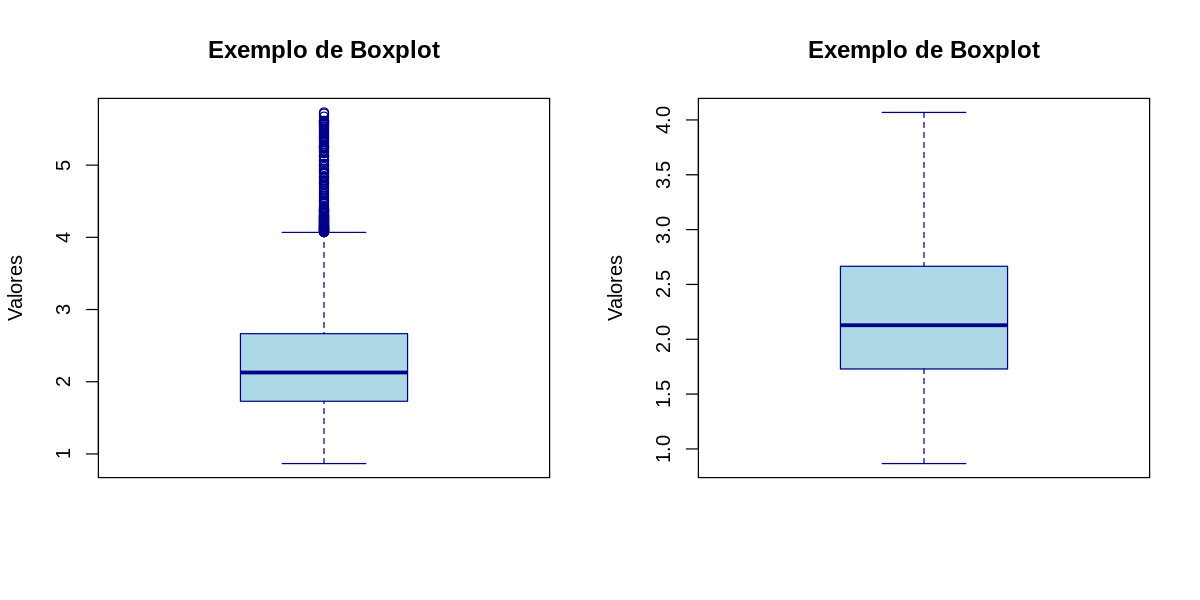

In [32]:
options(repr.plot.width = 10, repr.plot.height = 5)
par(mfrow=c(1,2))
boxplot(y,
main="Exemplo de Boxplot",
ylab="Valores",
col="lightblue",
border="darkblue",
notch=F)
boxplot(y,
main="Exemplo de Boxplot",
ylab="Valores",
col="lightblue",
border="darkblue",
notch=F,
outline=FALSE)

# **Histograma para target**

In [11]:
nclass.Sturges(y)
nclass.scott(y)
nclass.FD(y)

[1] 15

[1] 38

[1] 54

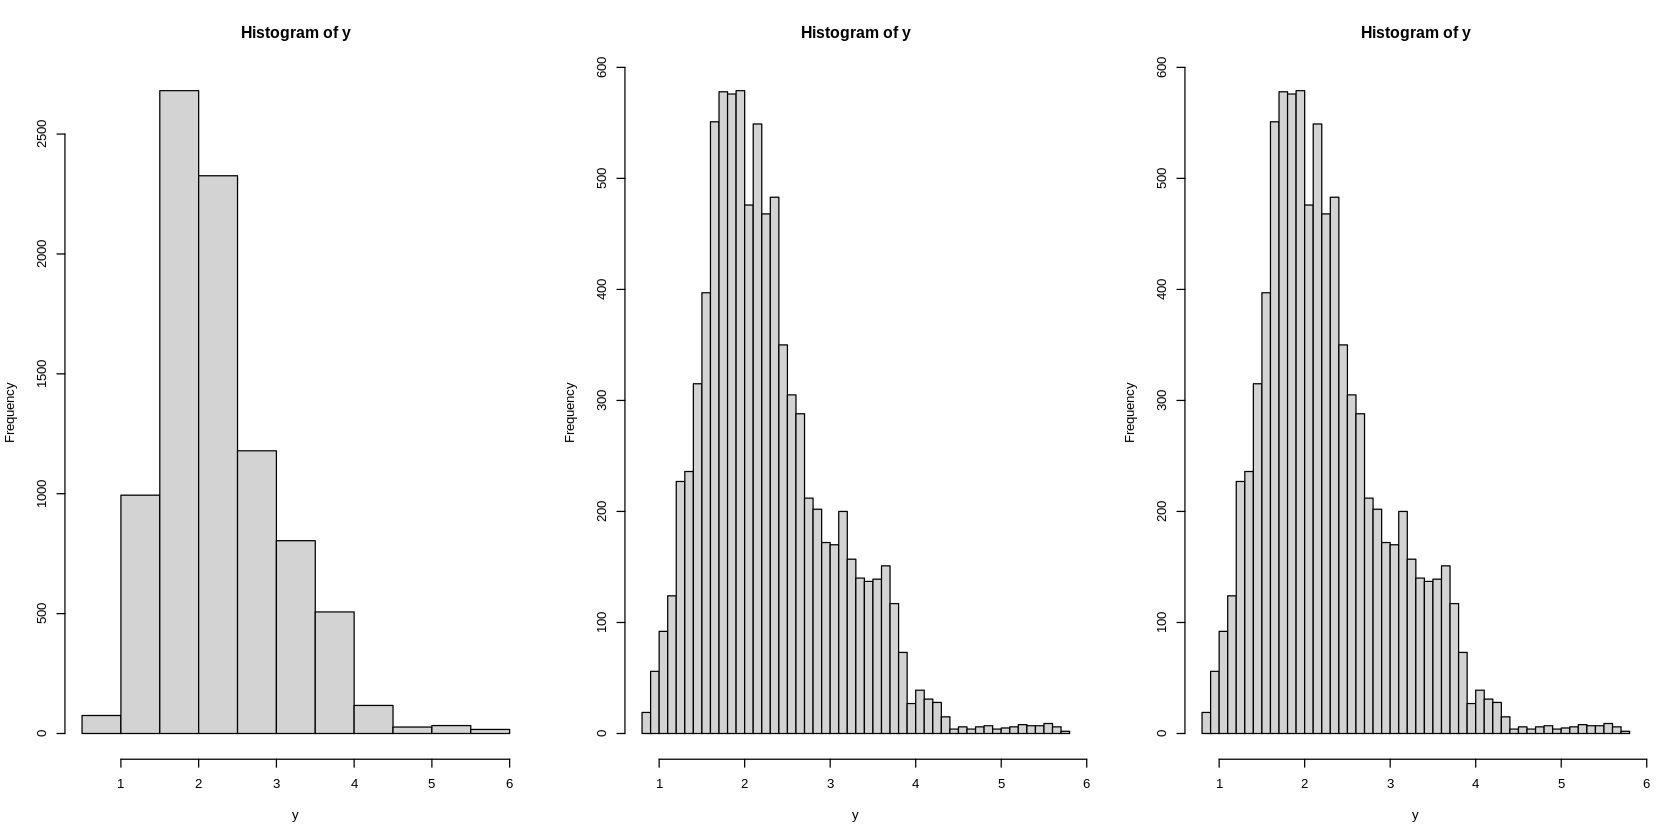

In [33]:
options(repr.plot.width = 14, repr.plot.height = 7)
par(mfrow=c(1,3))
hist(y, breaks=nclass.Sturges(y))
hist(y, breaks=nclass.FD(y))
hist(y, breaks=nclass.scott(y))

# **Verificando a distribuição das variaveis**

In [22]:
vars_numericas <- names(df)[sapply(df, is.numeric)]

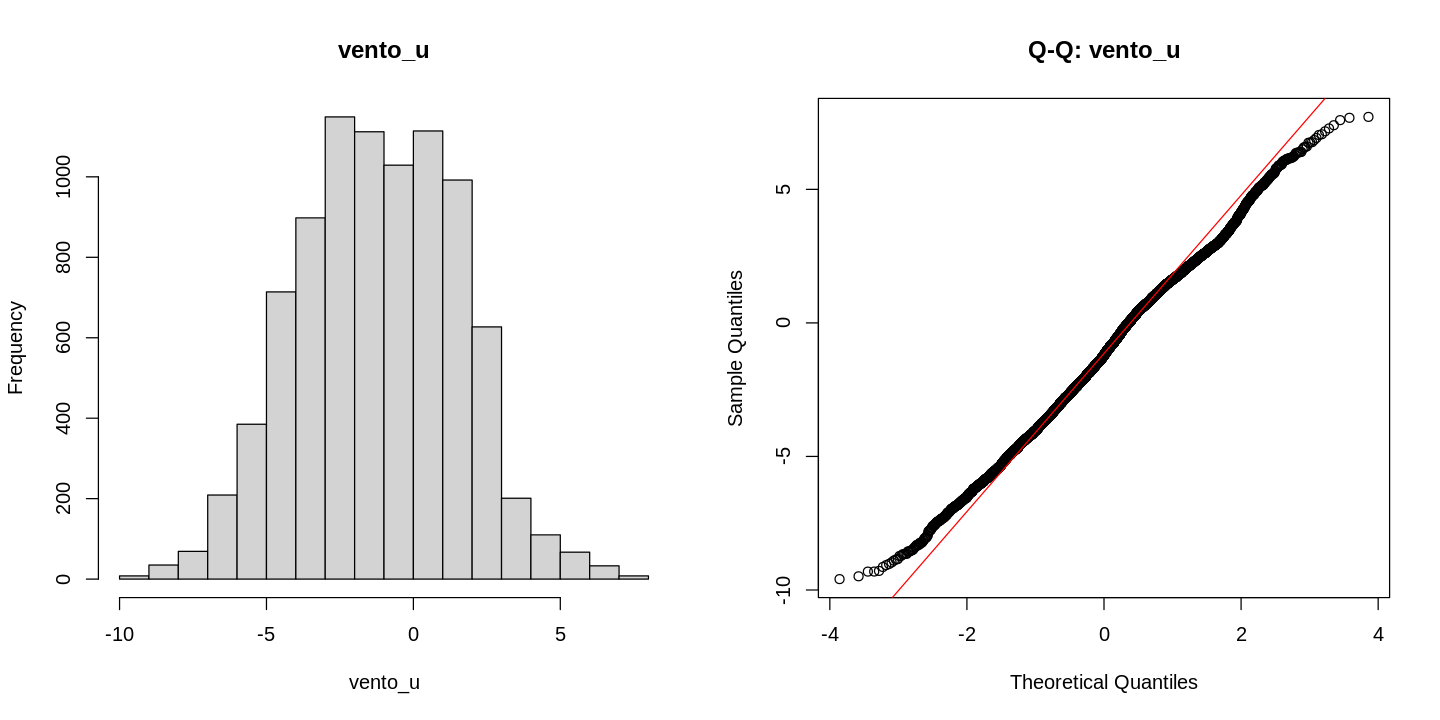

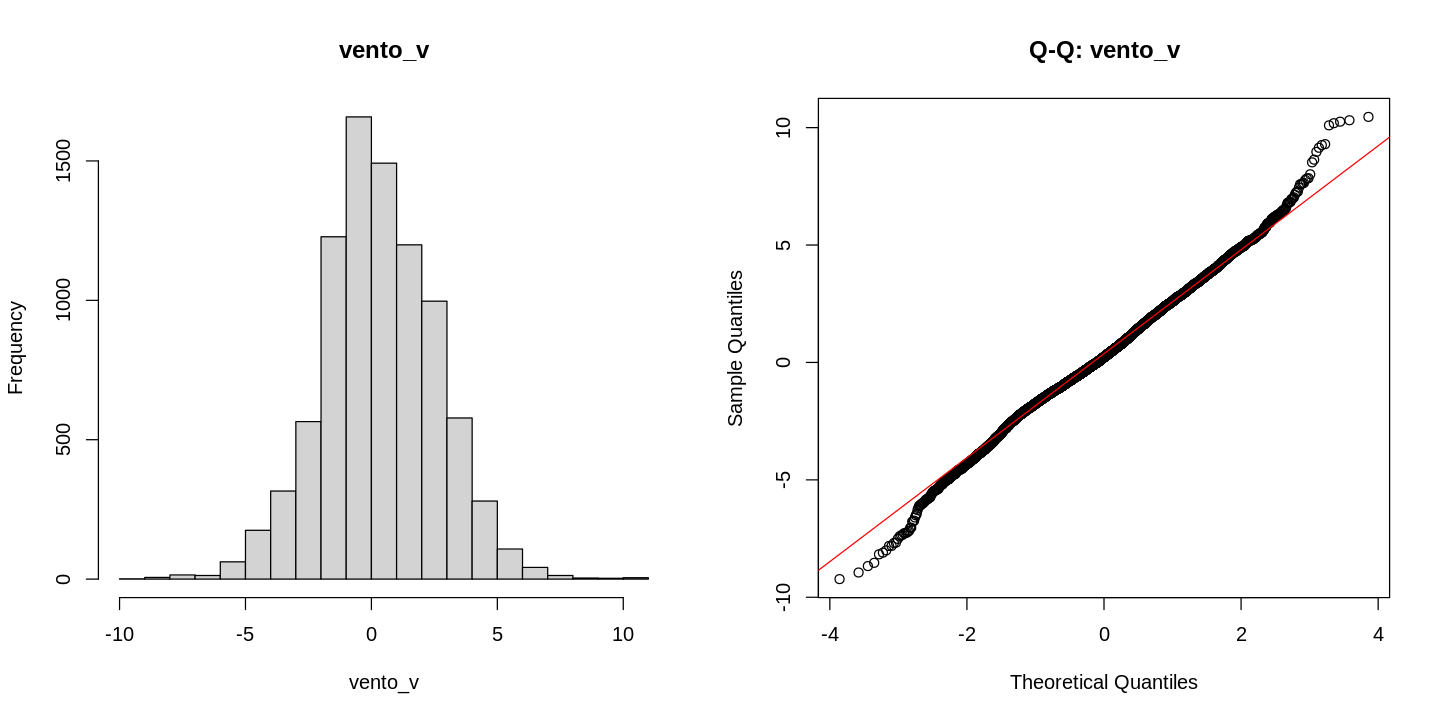

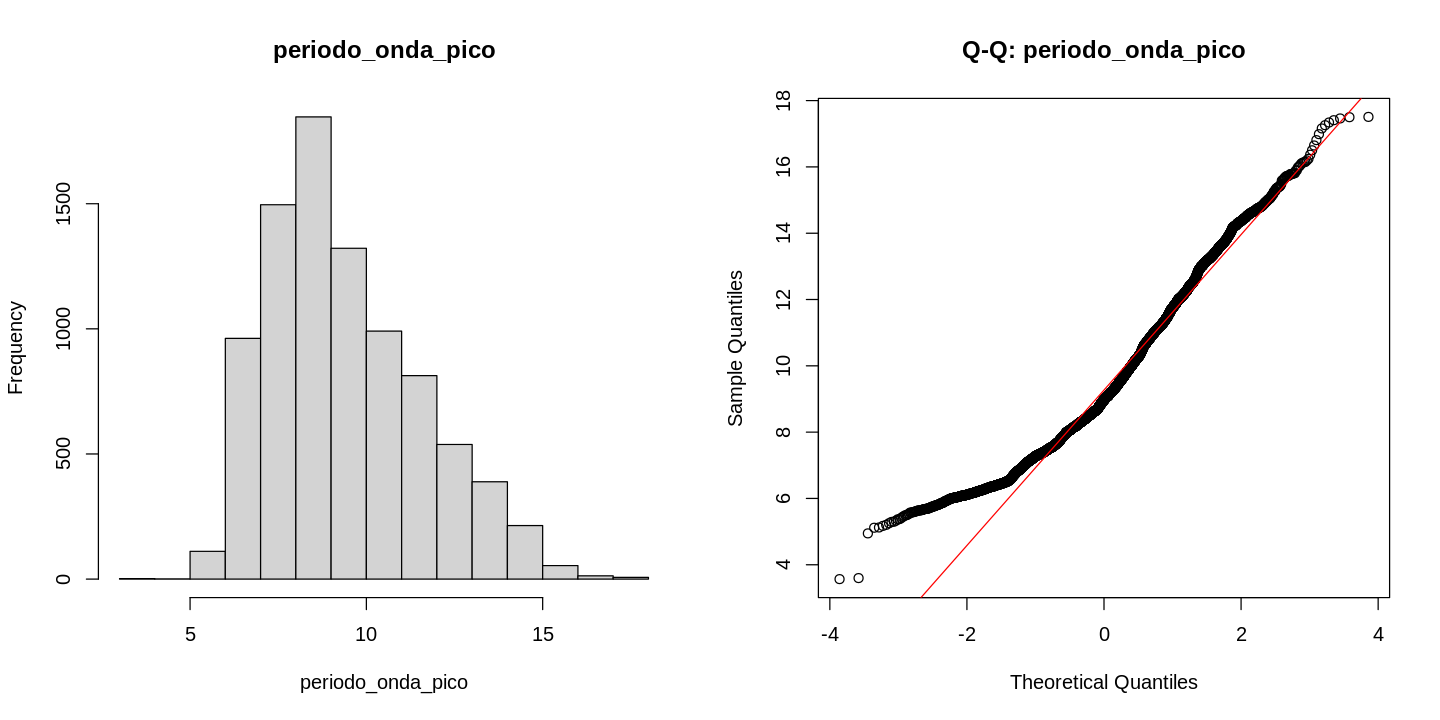

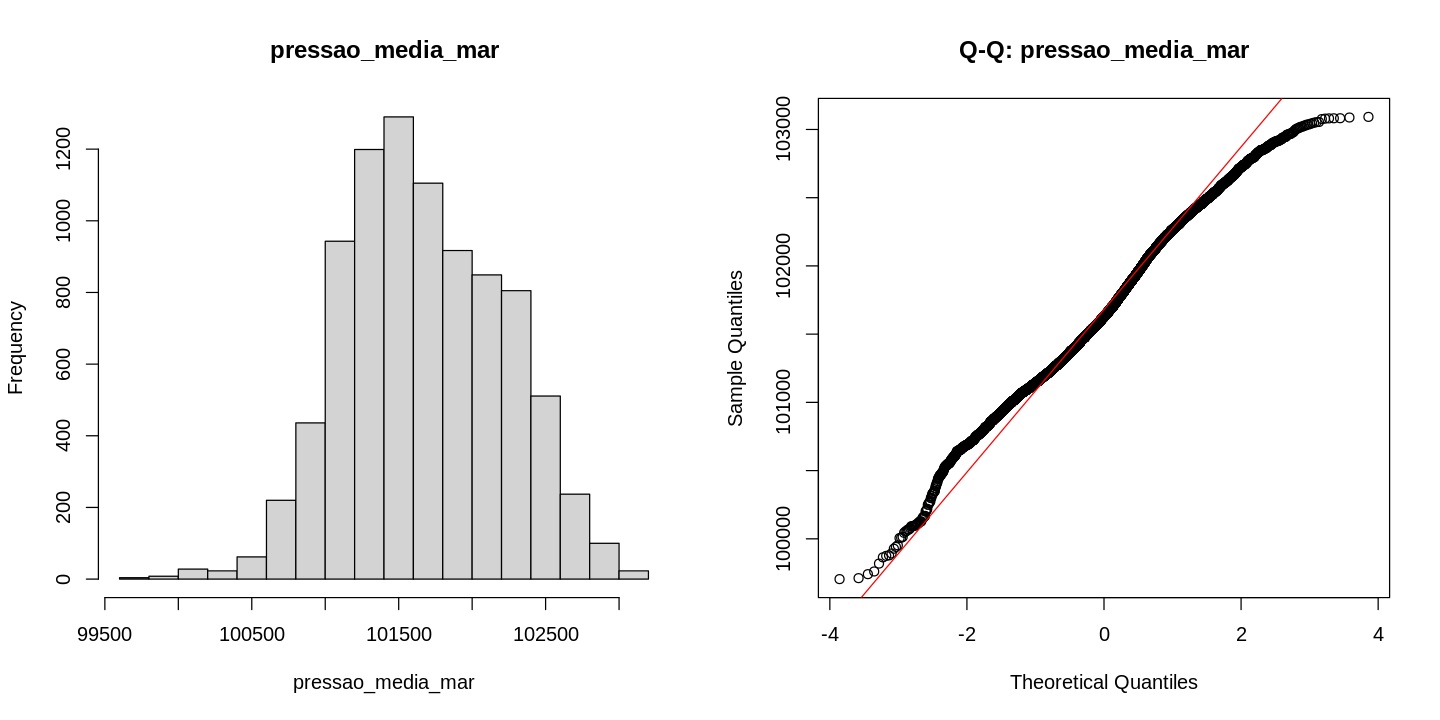

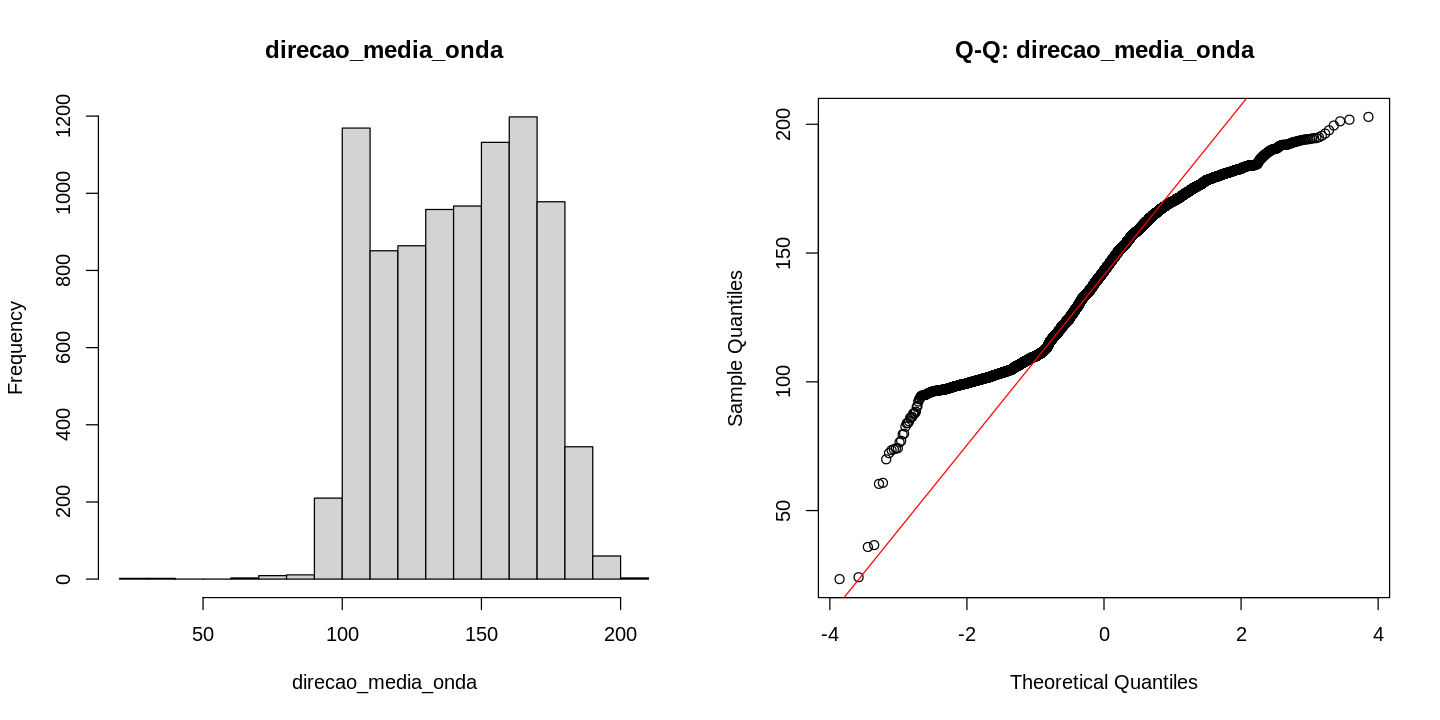

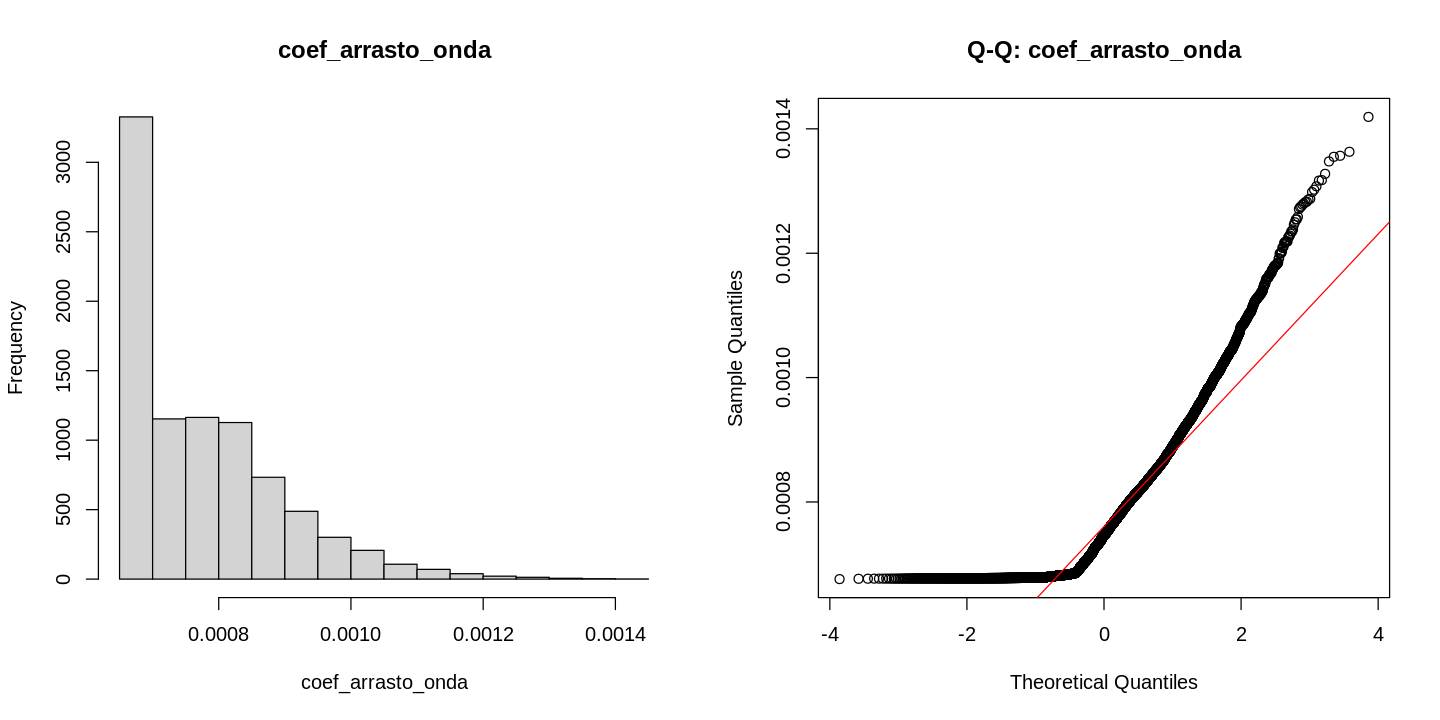

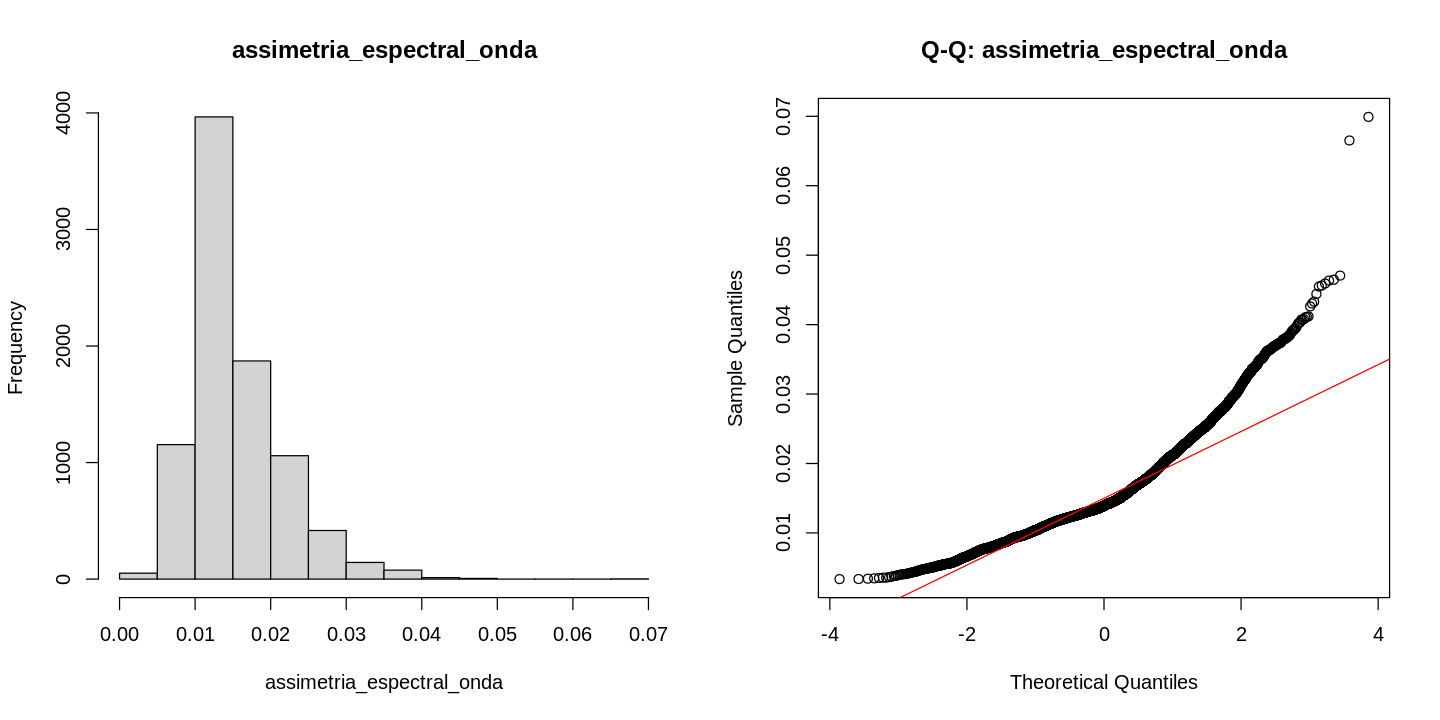

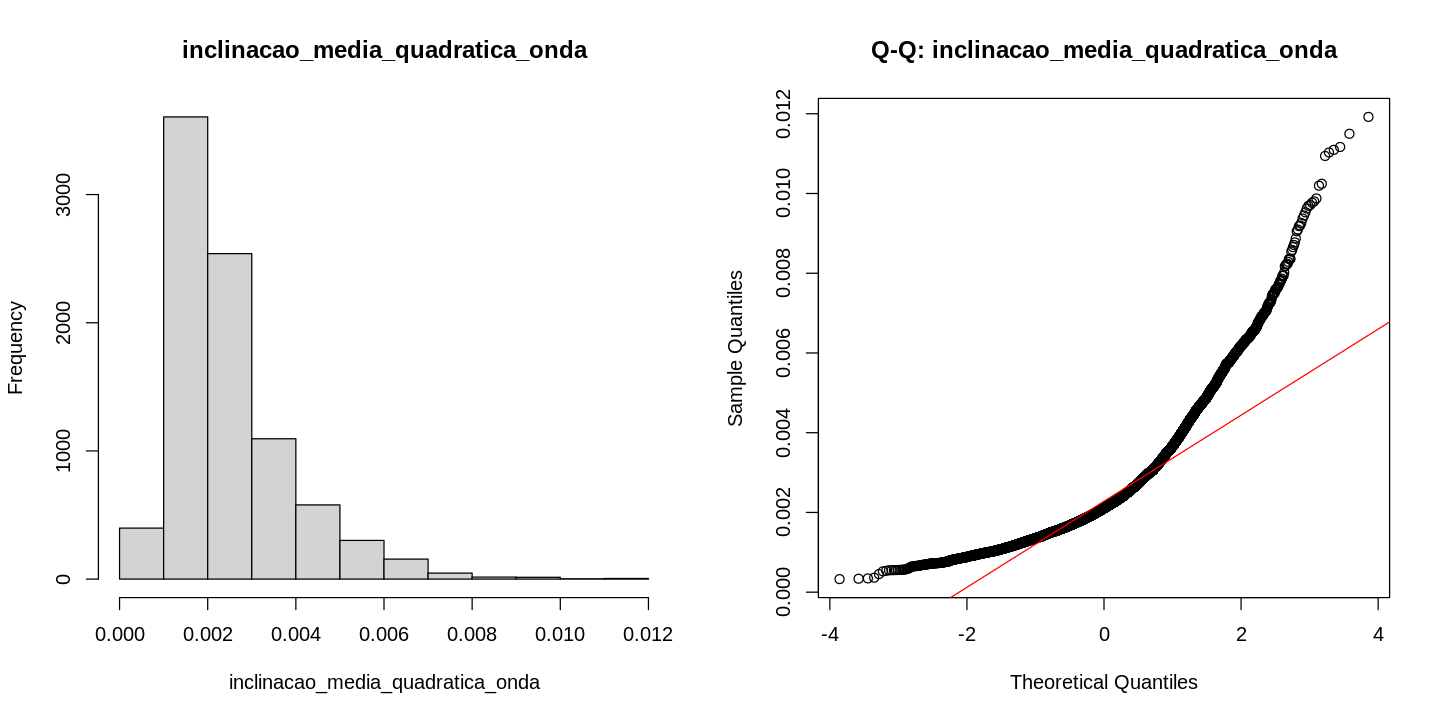

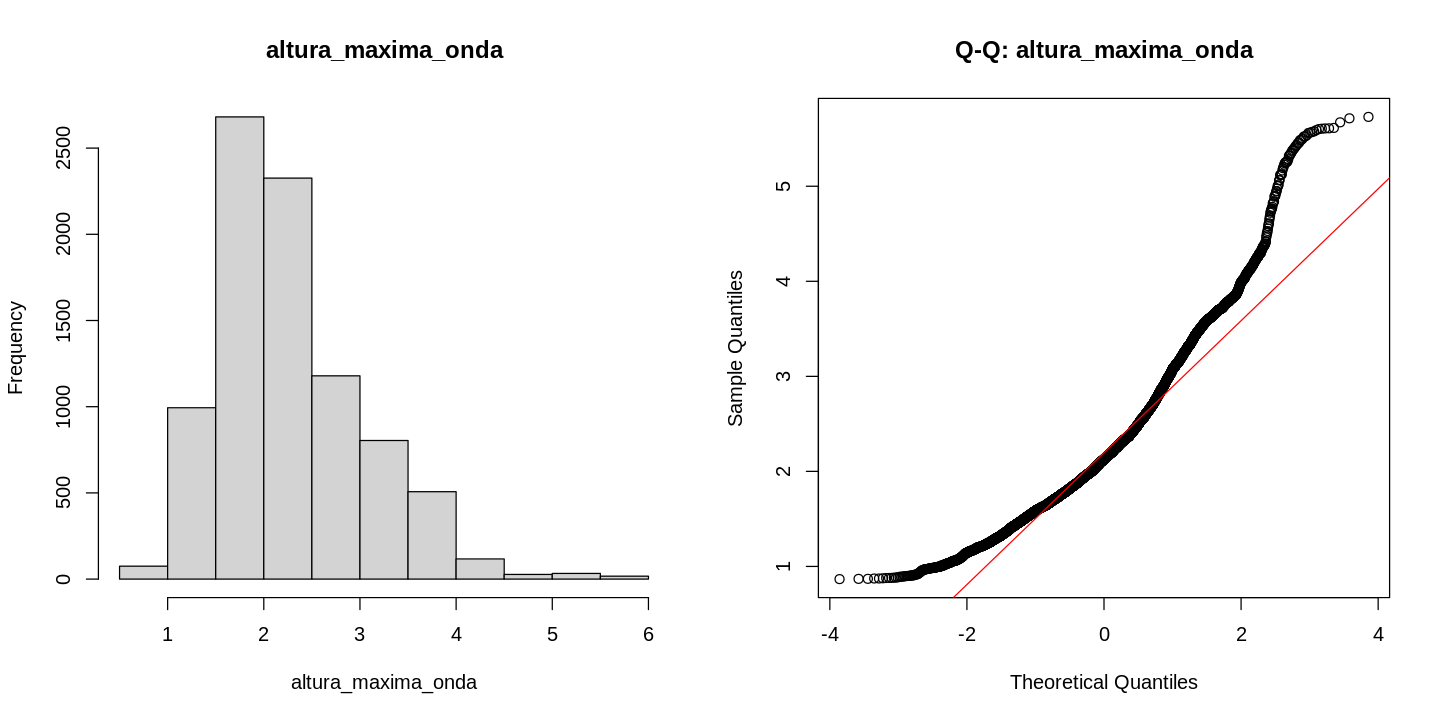

In [23]:
par(mfrow = c(1, 2))  # mantém o layout 2 colunas para cada iteração

for (var in vars_numericas) {
  hist(df[[var]], main = var, xlab = var)
  qqnorm(df[[var]], main = paste("Q-Q:", var))
  qqline(df[[var]], col = "red")
}

par(mfrow = c(1, 1))  # reseta o layout ao terminar

# **Verificando outliers das variáveis**

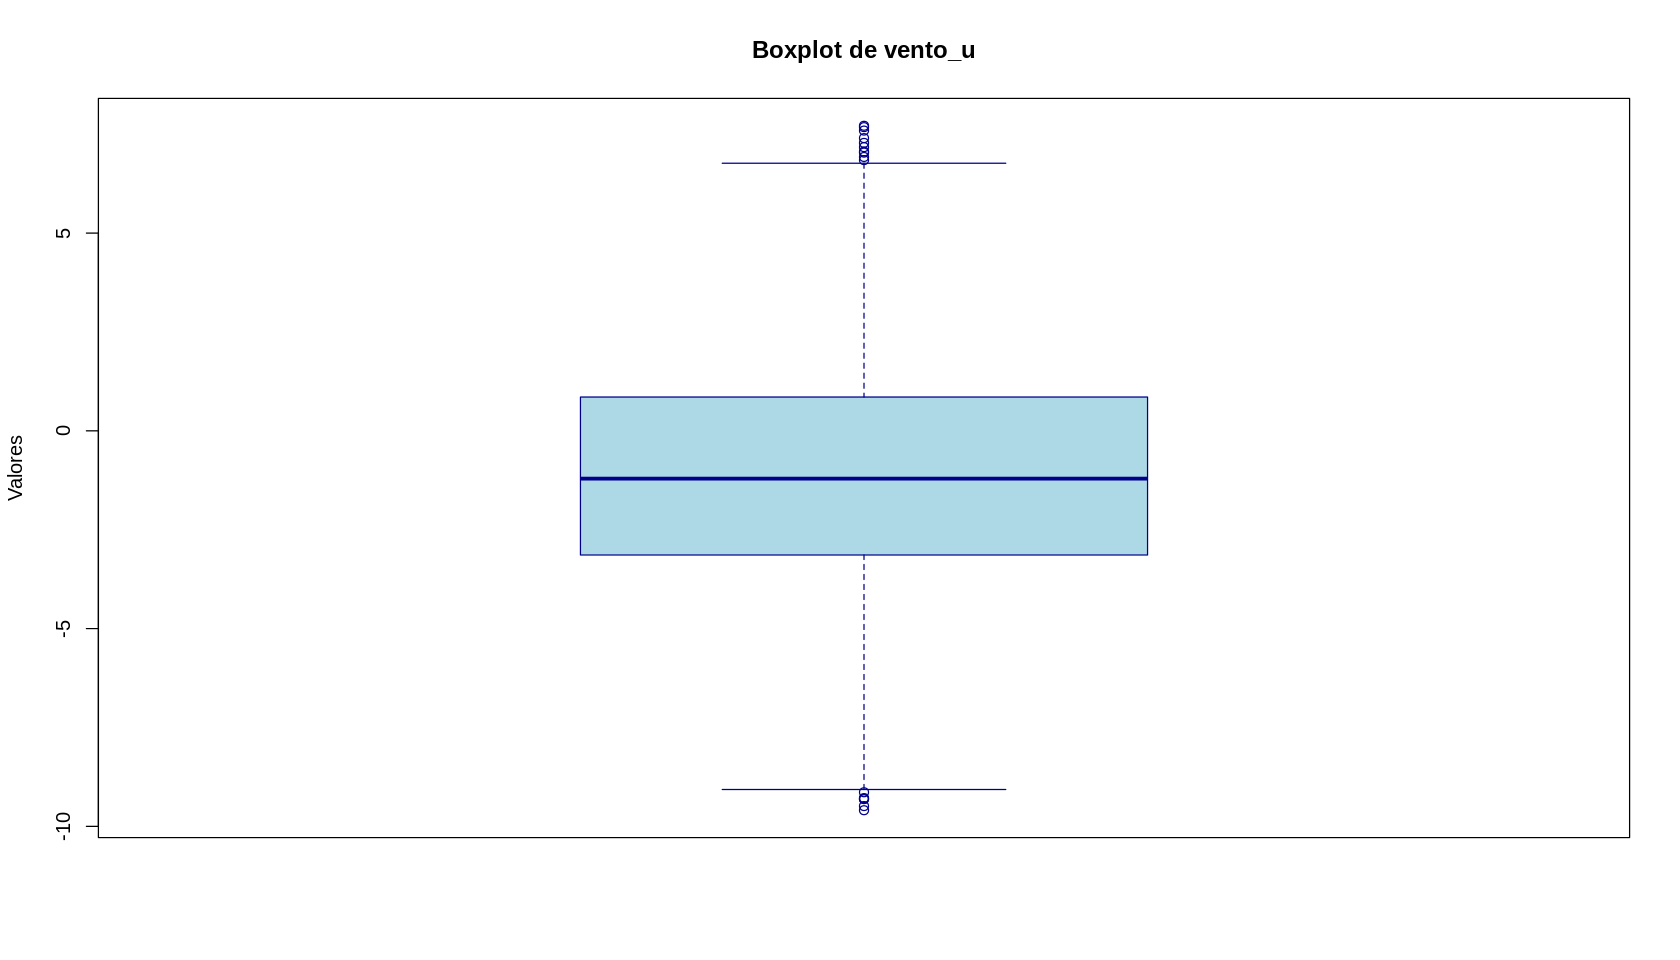

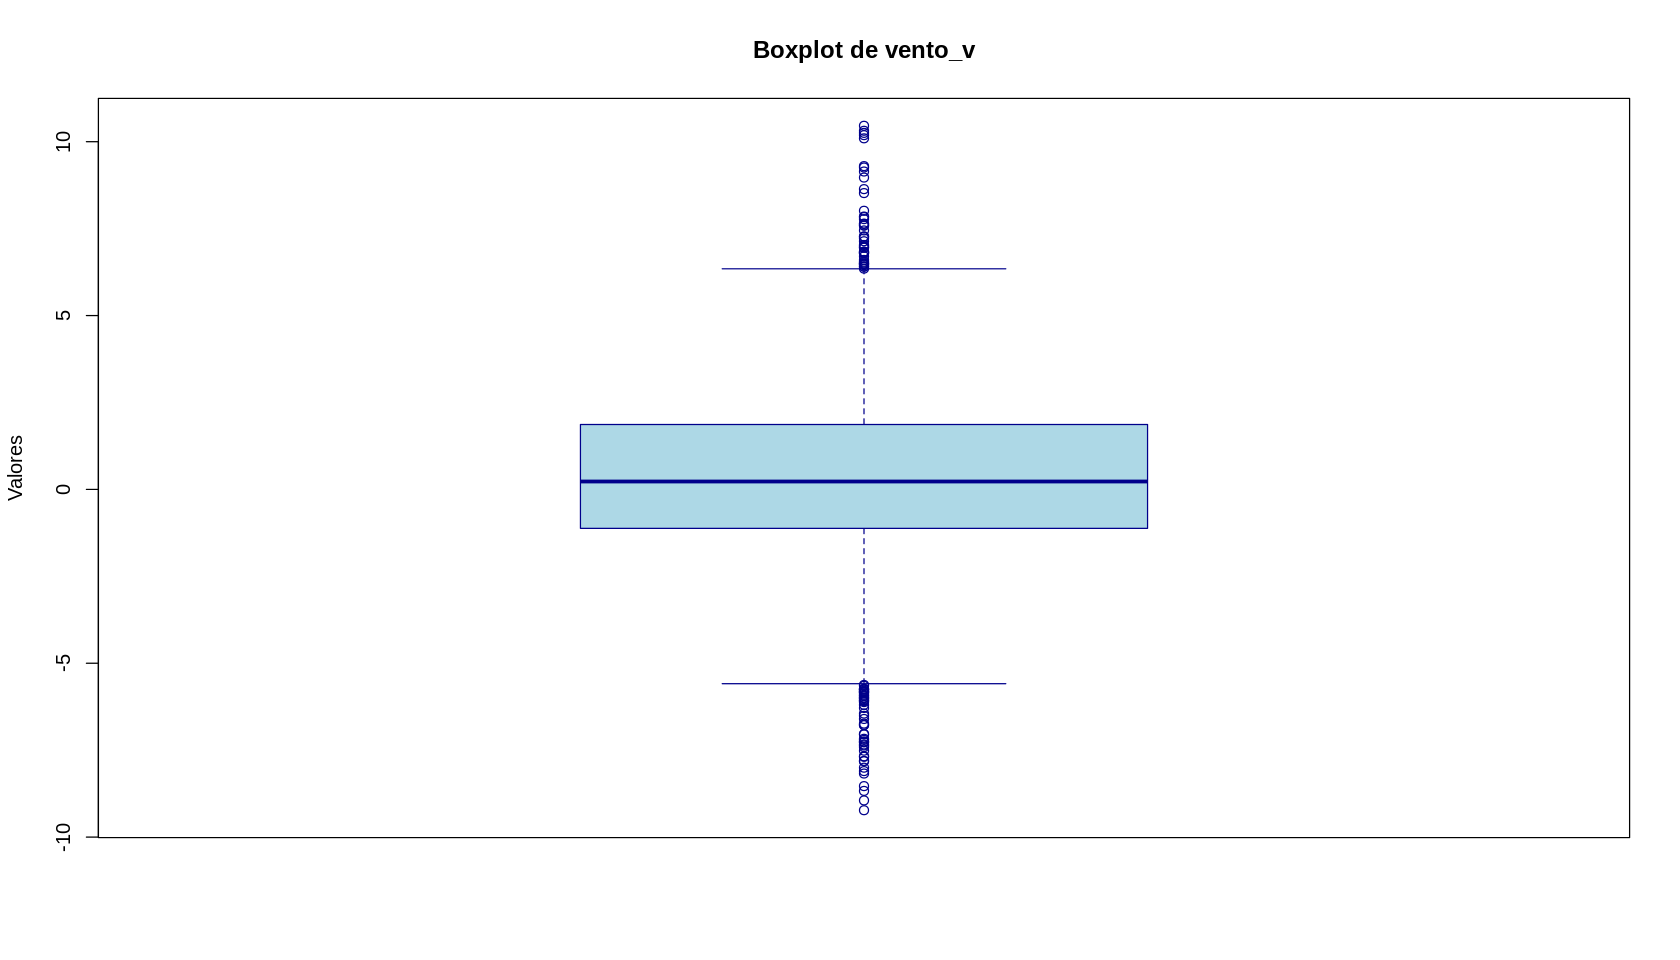

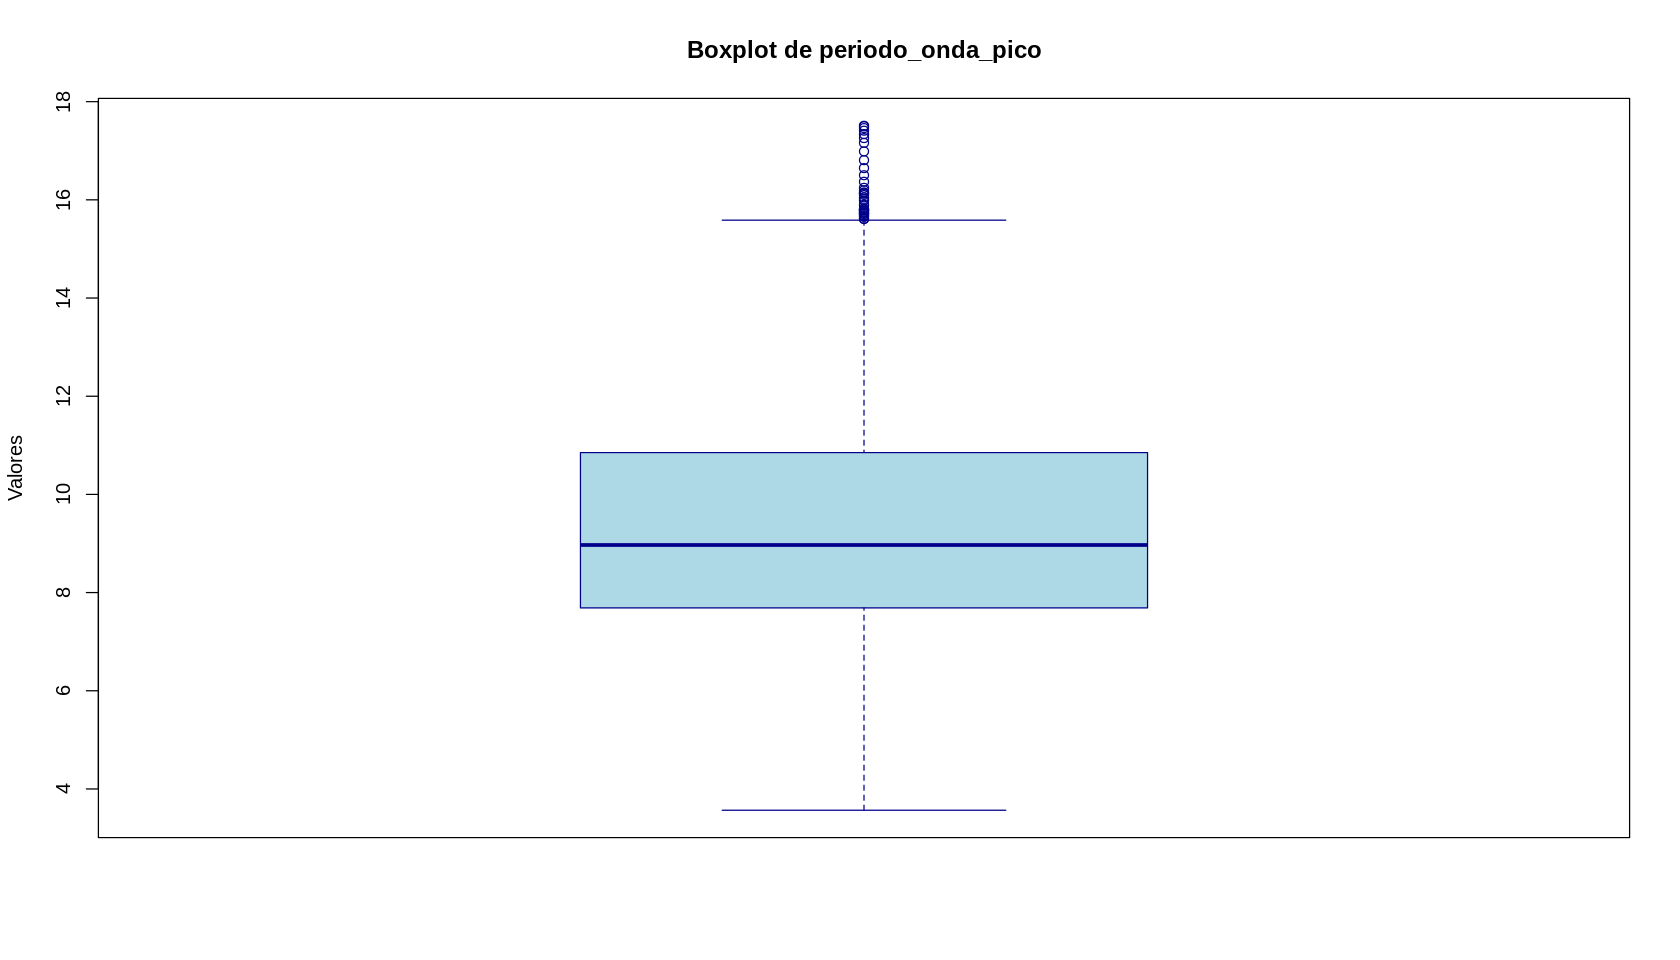

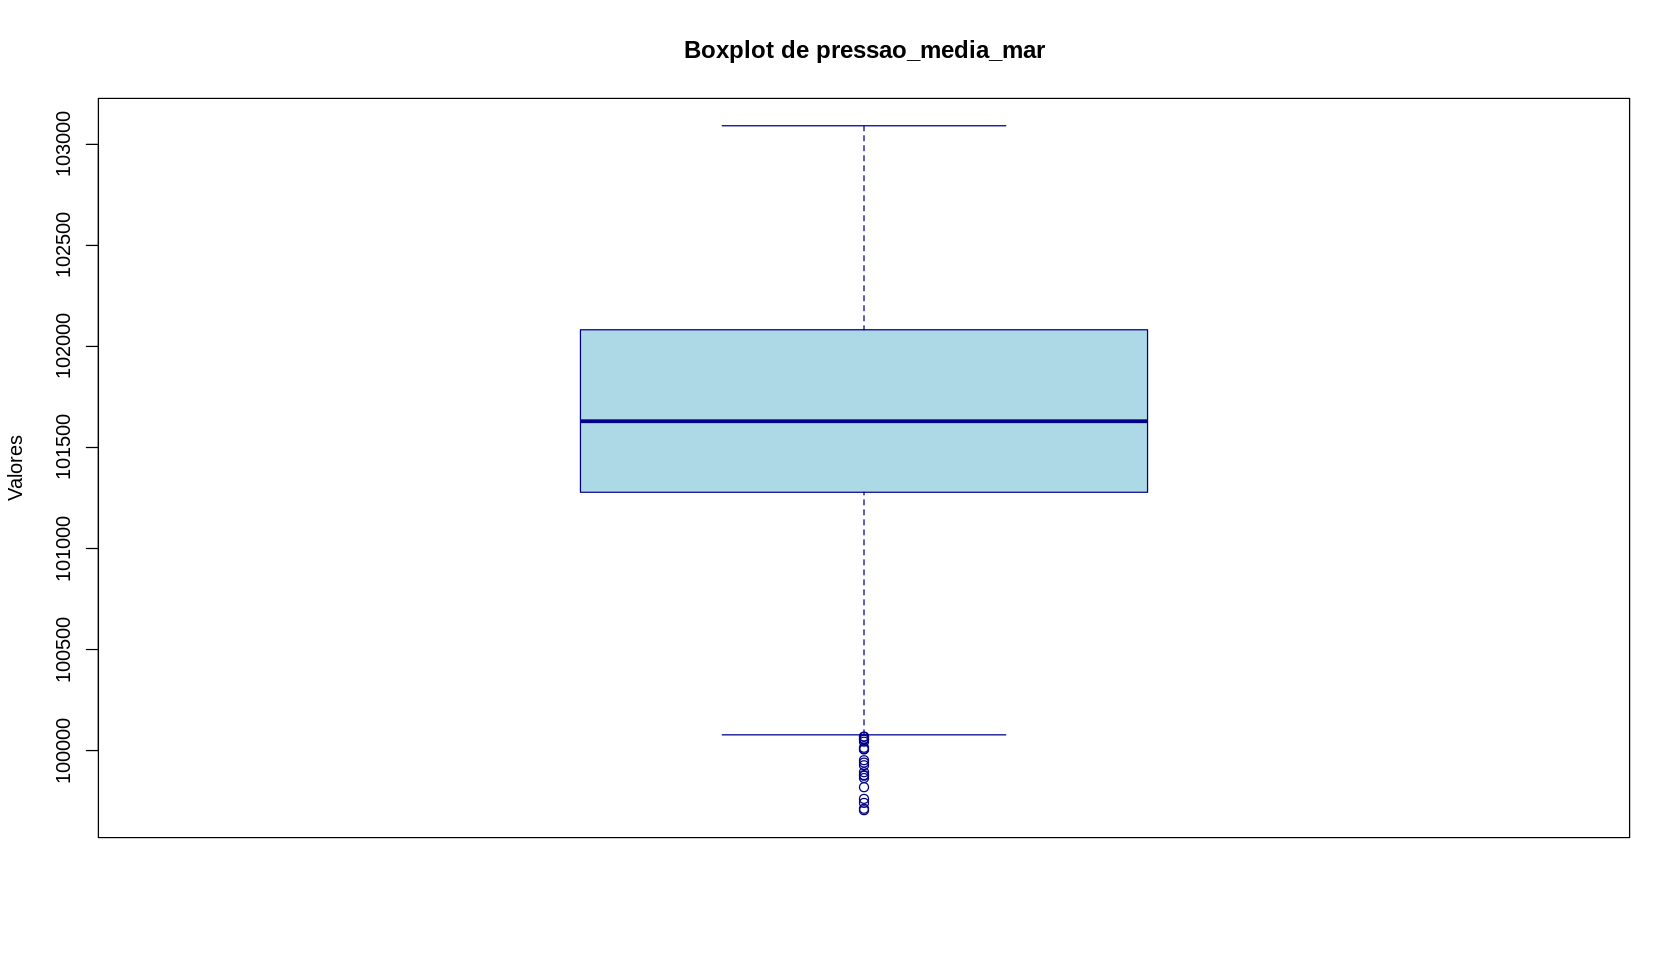

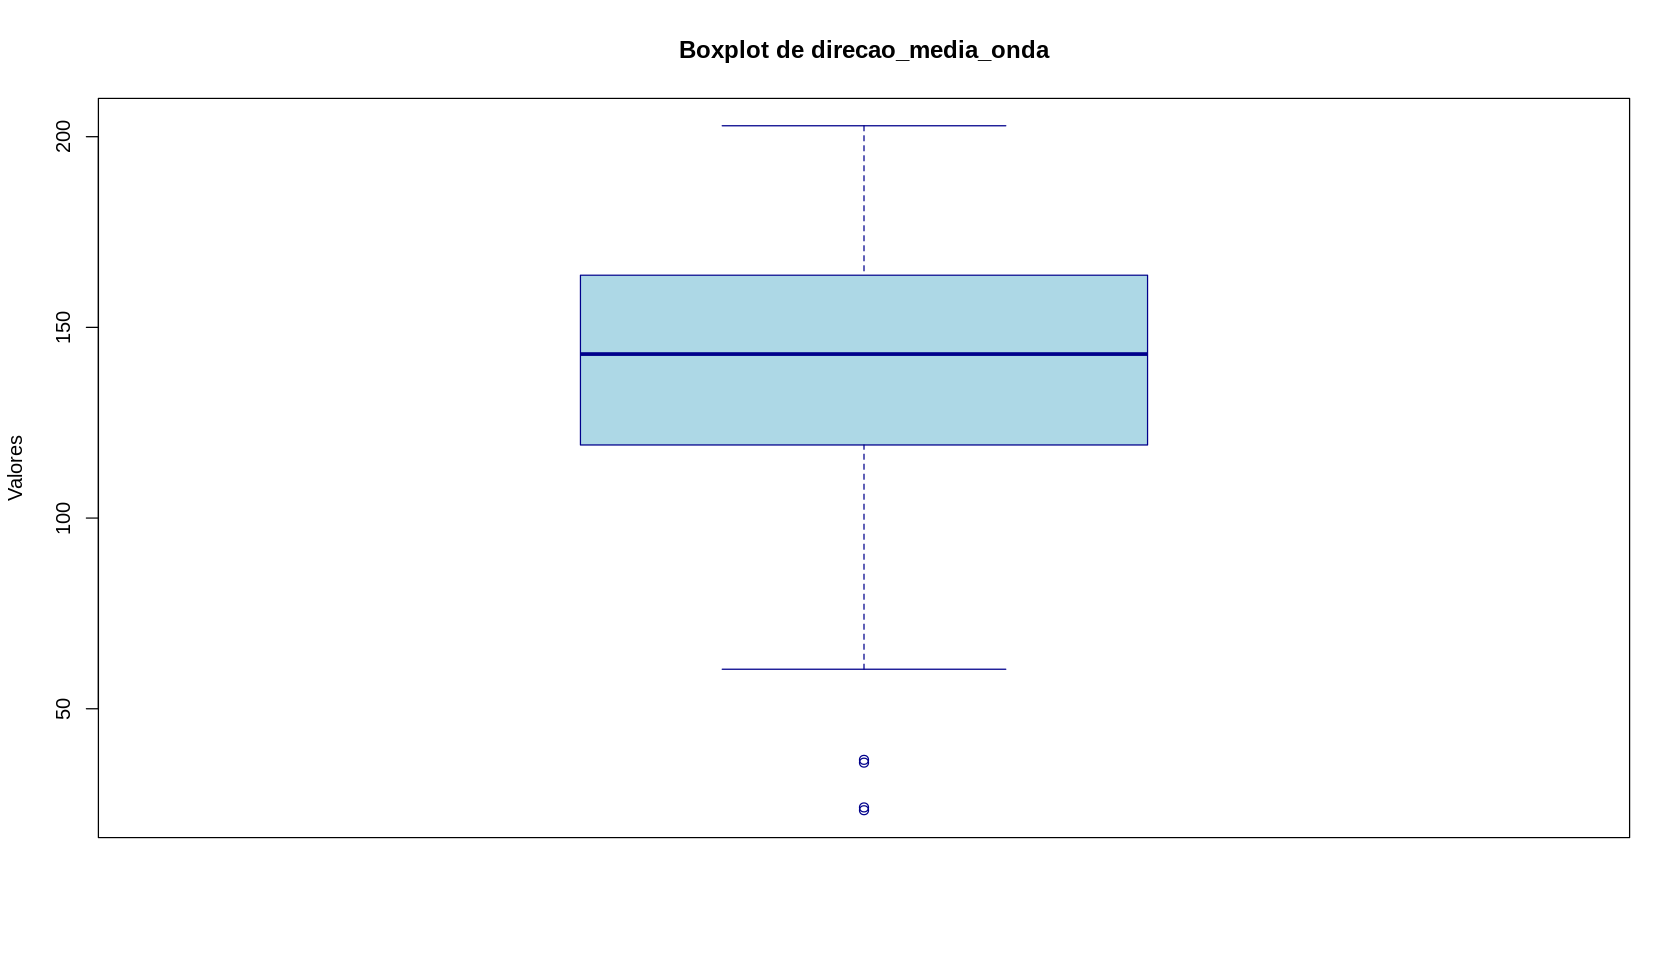

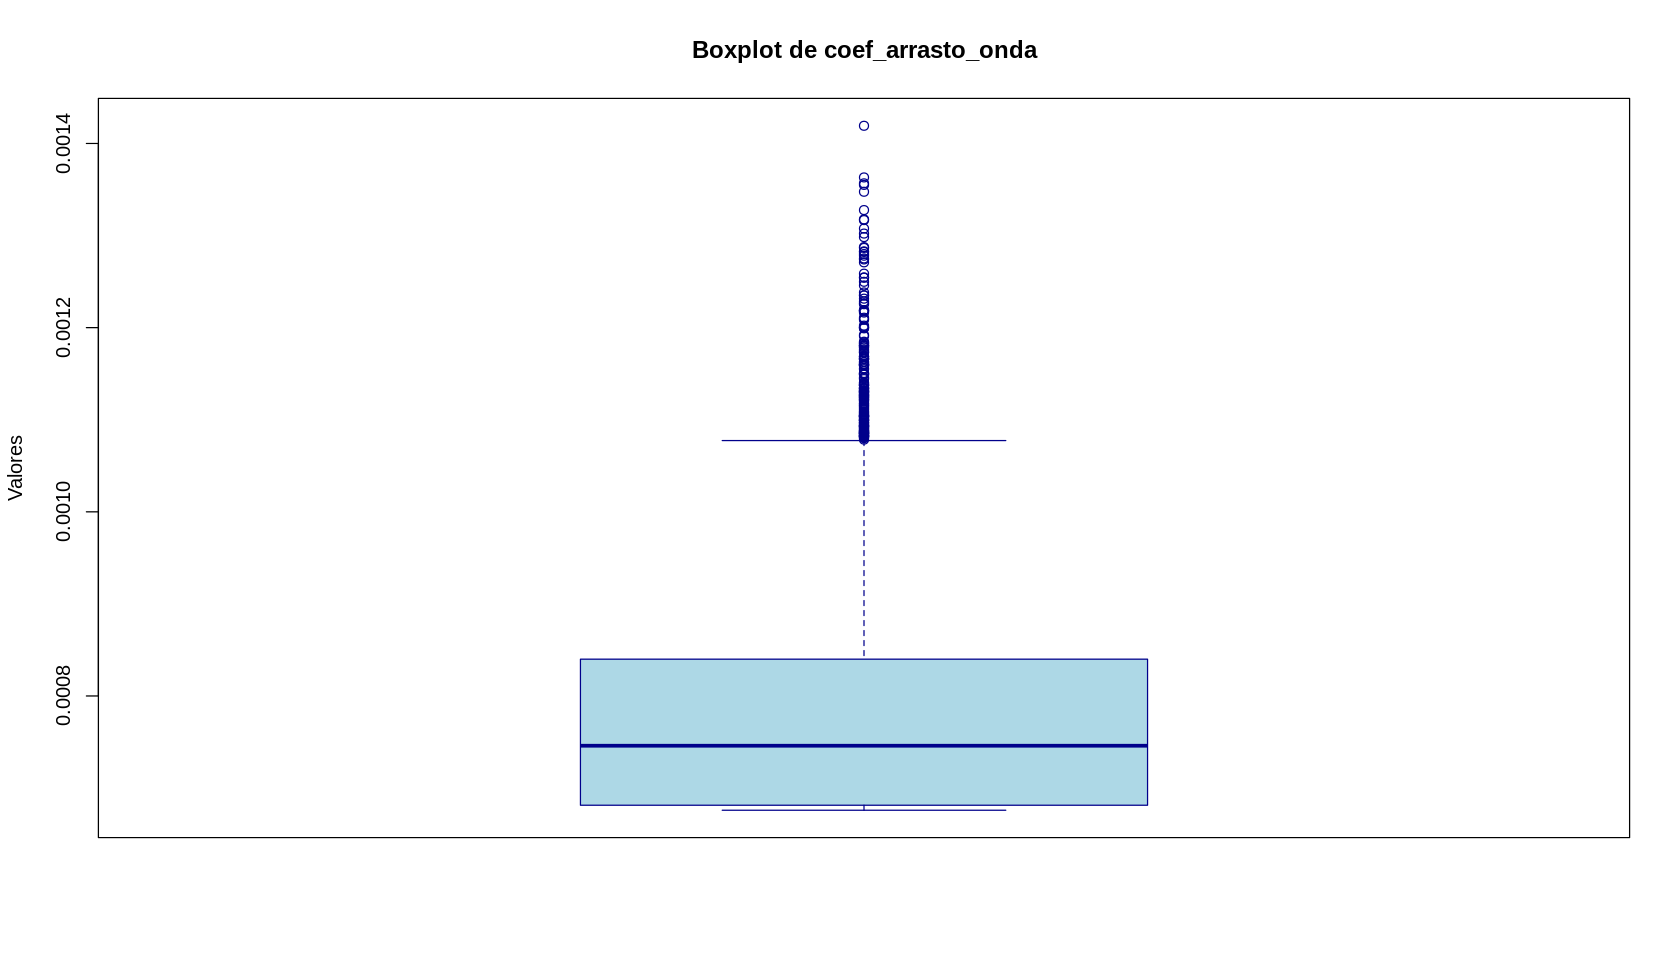

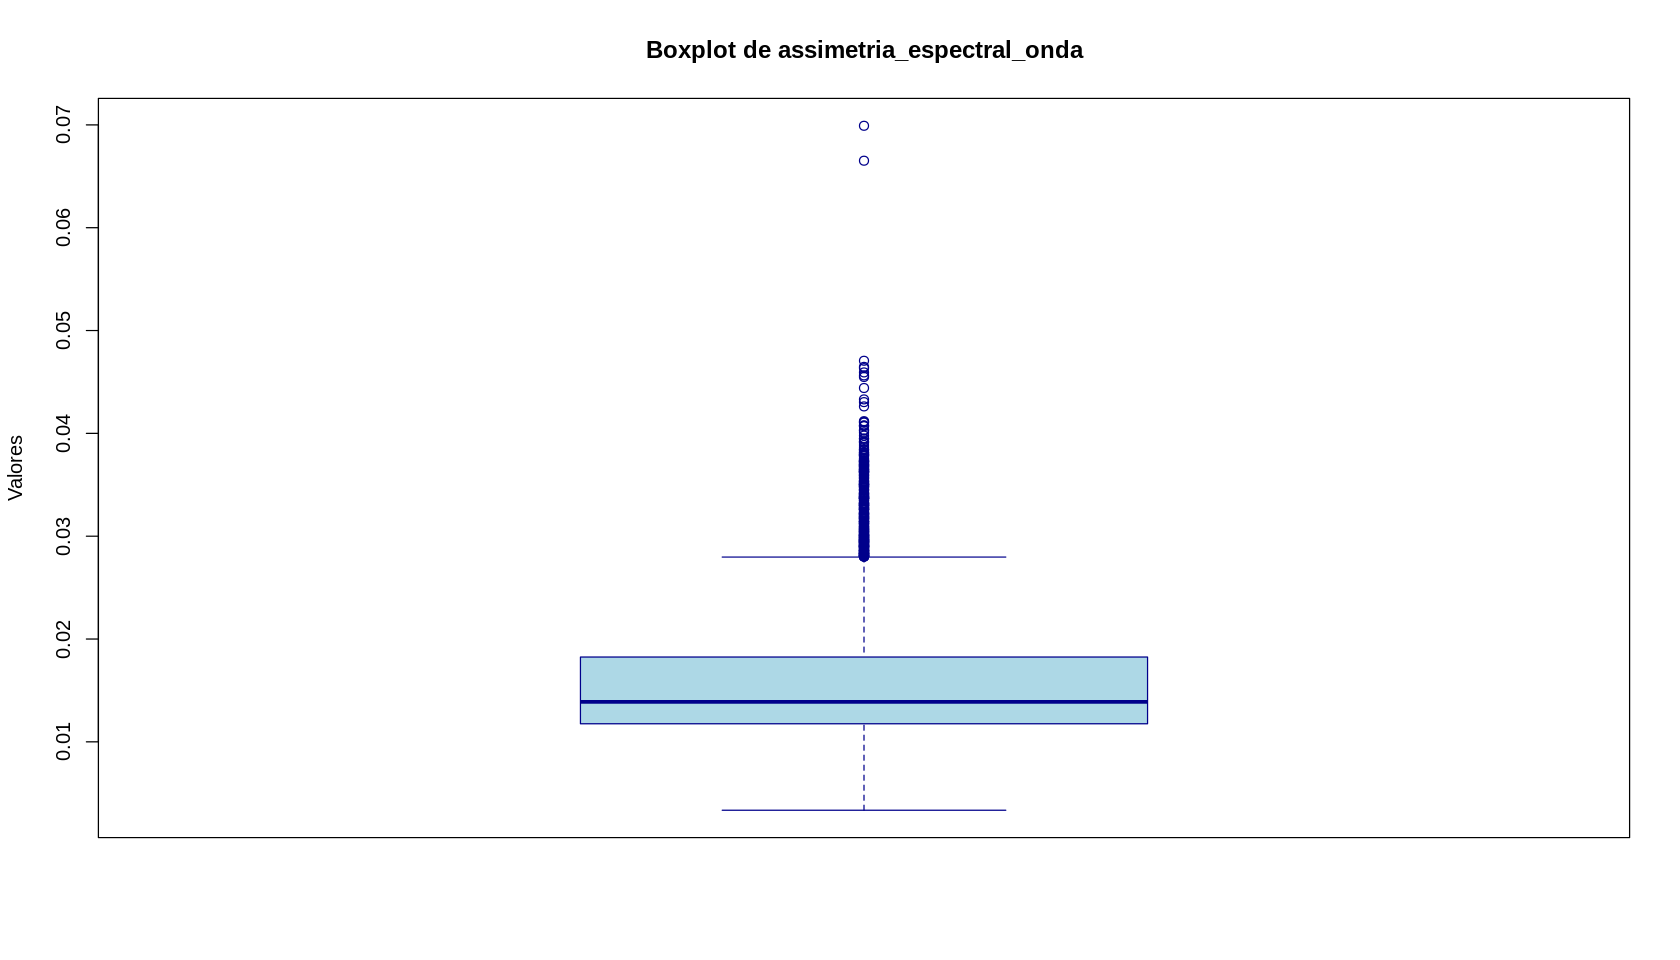

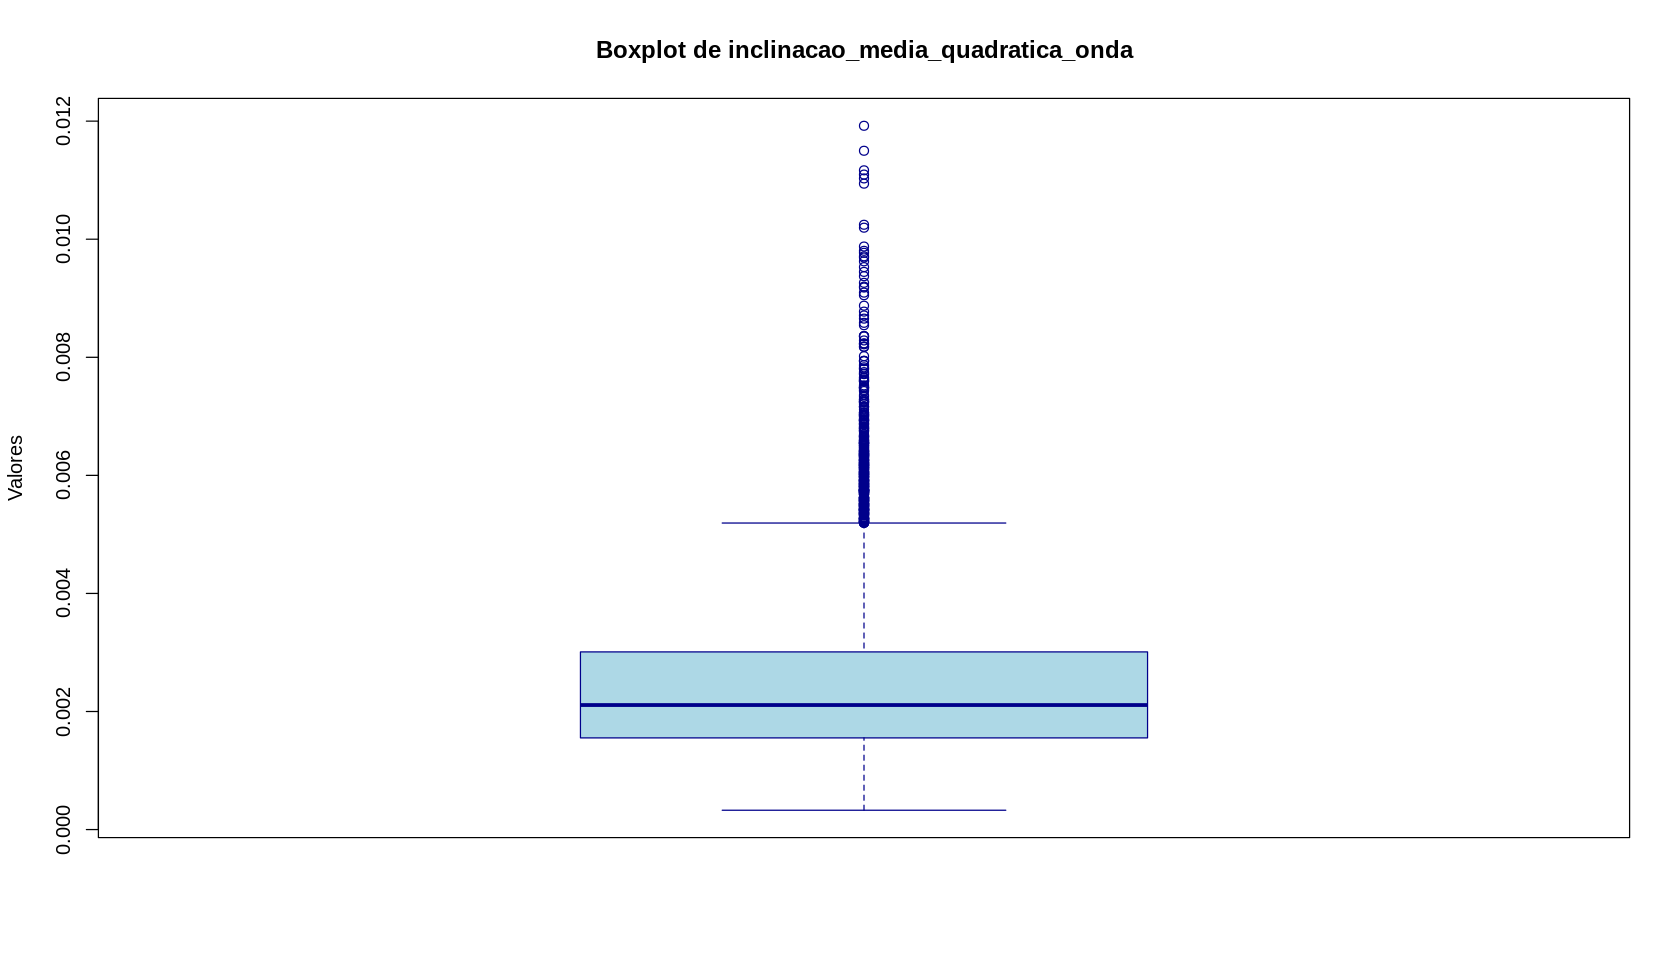

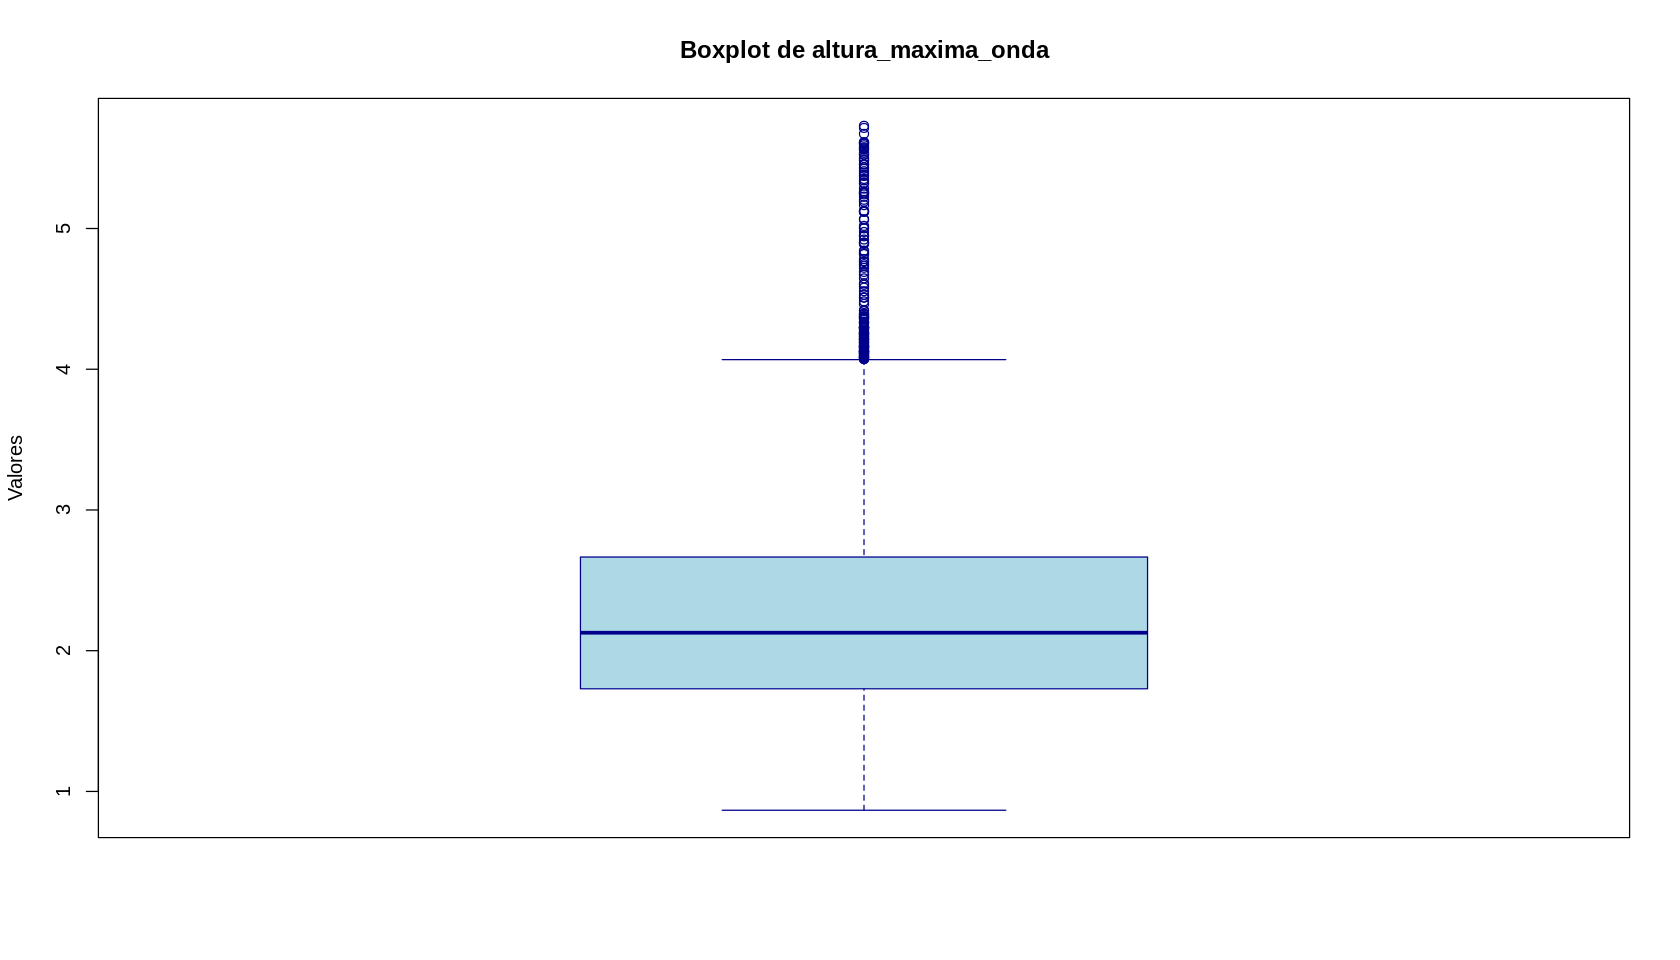

In [35]:
options(repr.plot.width = 14, repr.plot.height = 8)

for (var in vars_numericas){
  boxplot(df[[var]],
          main=paste("Boxplot de", var),
          ylab="Valores",
          col="lightblue",
          border="darkblue",
          notch=F
          )
}

# **Criando variáveis qualitativas ordinais com intervalos e plotando histogramas**

In [25]:
# ============================================================
# CÉLULA 36 — Criação das colunas qualitativas de intervalos
# (df e ggplot2 já carregados acima)
# ============================================================

# Pega o nome de todas as colunas do df que são numéricas.
# sapply() percorre cada coluna e aplica is.numeric(), retornando TRUE/FALSE.
# names()[...] filtra só os nomes onde o resultado foi TRUE.
vars_numericas <- names(df)[sapply(df, is.numeric)]

# Variáveis que mostraram distribuição suficientemente normal no Q-Q plot
# e têm outliers simétricos/leves o suficiente para usar Scott.
# As demais usarão FD, que é mais robusto a assimetria e outliers.
vars_scott <- c("vento_u", "vento_v", "pressao_media_mar")

# Função que, dado um vetor x e um nome de método, devolve os breakpoints
# (pontos de corte) que definem os intervalos do histograma.
calc_breaks <- function(x, metodo) {

  # Remove NAs antes de qualquer cálculo para evitar erros nas funções abaixo.
  x_limpo <- x[!is.na(x)]

  # Cada método usa uma fórmula diferente para sugerir o número ideal de classes:
  #
  # - Scott: h = 3.49 * sd * n^(-1/3). Usa o desvio padrão, assume normalidade.
  #   Adequado quando a distribuição é aproximadamente simétrica e os outliers
  #   são poucos — o n grande (8760) atenua o impacto deles no sd.
  #
  # - FD (Freedman-Diaconis): h = 2 * IQR * n^(-1/3). Usa o IQR no lugar do sd,
  #   sendo mais robusto a outliers e assimetria — ideal para fenômenos físicos
  #   como altura de ondas, período, direção, que não seguem distribuição normal.
  n <- switch(metodo,
    "Scott" = nclass.scott(x_limpo),
    "FD"    = nclass.FD(x_limpo)
  )

  # Cria n+1 pontos igualmente espaçados entre o mínimo e o máximo do vetor.
  # n classes precisam de n+1 pontos de corte (como uma cerca com n+1 mourões).
  seq(min(x_limpo), max(x_limpo), length.out = n + 1)
}

# Para cada variável numérica, decide qual método usar e cria uma única
# coluna qualitativa no dataframe — sem versões paralelas por método.
for (var in vars_numericas) {

  # Se a variável está na lista de normais, usa Scott; caso contrário, FD.
  # %in% é o operador de pertencimento do R — equivalente ao "in" do Python.
  met <- if (var %in% vars_scott) "Scott" else "FD"

  brks <- calc_breaks(df[[var]], met)

  # Nome da coluna: "vento_u_intervalo", "altura_maxima_onda_intervalo", etc.
  # Sufixo fixo "_intervalo" deixa claro que é a coluna qualitativa da variável.
  df[[paste0(var, "_", met)]] <- cut(
    df[[var]],
    breaks         = brks,
    include.lowest = TRUE,  # inclui o valor mínimo exato na primeira classe
    right          = TRUE,  # intervalos fechados à direita: (a, b]
    ordered_result = TRUE   # fator ordenado — respeita a sequência dos intervalos
  )
}

# Tabela resumo: mostra qual método foi aplicado e quantas classes gerou
# para cada variável. Útil para documentar e justificar as escolhas.
tabela <- data.frame(
  variavel = vars_numericas,
  metodo   = ifelse(vars_numericas %in% vars_scott, "Scott", "FD")
)
tabela$n_classes <- sapply(vars_numericas, function(v) {
  met <- if (v %in% vars_scott) "Scott" else "FD"
  nlevels(df[[paste0(v, "_", met)]])
})
print(tabela)




                          variavel metodo n_classes
1                          vento_u  Scott        38
2                          vento_v  Scott        52
3                periodo_onda_pico     FD        46
4                pressao_media_mar  Scott        38
5               direcao_media_onda     FD        42
6                coef_arrasto_onda     FD        49
7        assimetria_espectral_onda     FD       106
8 inclinacao_media_quadratica_onda     FD        83
9               altura_maxima_onda     FD        54


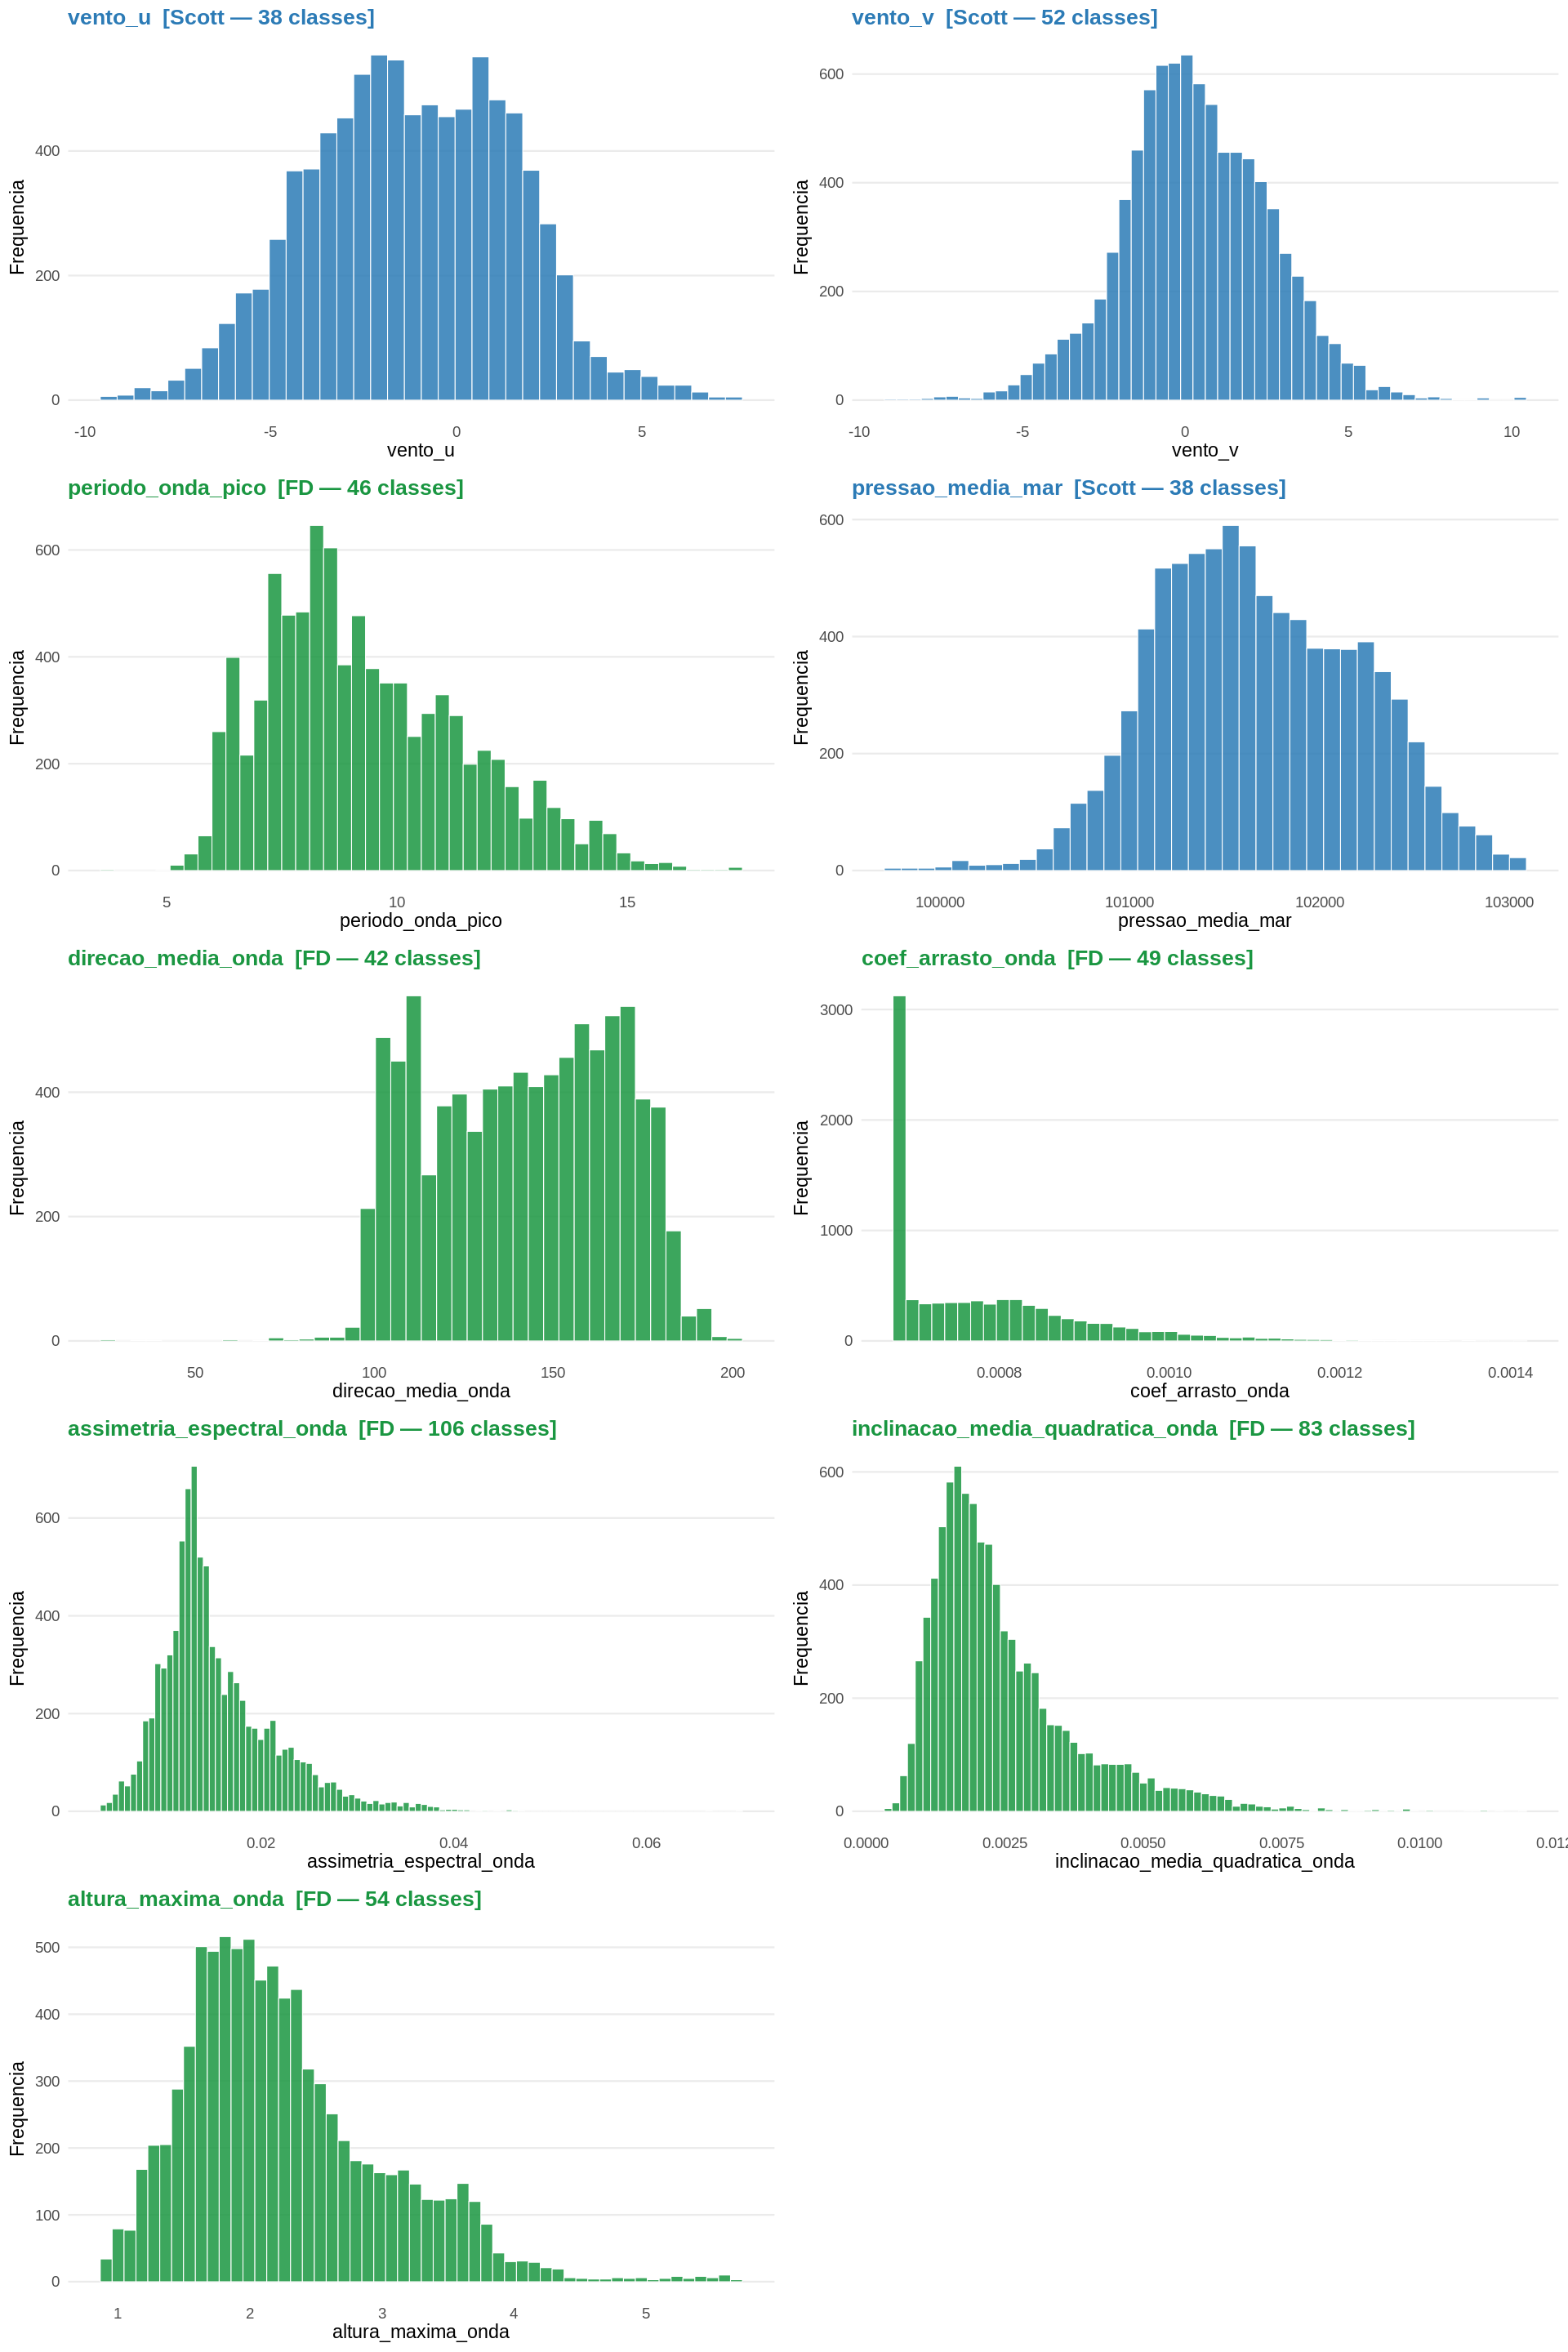

In [29]:
# ============================================================
# CÉLULA 37 — Histogramas por variável (método escolhido)
# ============================================================

# gridExtra permite organizar múltiplos gráficos ggplot lado a lado
# com grid.arrange() — o ggplot2 sozinho não faz isso nativamente.
library(gridExtra)
library(ggplot2) # Adicionando o carregamento da biblioteca ggplot2

options(repr.plot.width = 16, repr.plot.height = 24) #controlam o tamanho da figura renderizada no notebook — largura e altura em polegadas.

# Cores por método — Scott em azul, FD em verde.
cores <- c(Scott = "#2C7BB6", FD = "#1A9641")

# Para cada variável numérica, gera um histograma com o método escolhido
# e ao lado o Q-Q plot, para visualizar distribuição e normalidade juntos.
plots_lista <- lapply(vars_numericas, function(var) {

  met   <- if (var %in% vars_scott) "Scott" else "FD"
  brks  <- calc_breaks(df[[var]], met)
  n_cl  <- length(brks) - 1

  # Histograma com os breakpoints exatos do método escolhido.
  # .data[[var]] é necessário dentro de lapply para referenciar a coluna
  # pelo nome guardado em variável — aes(x = var) não funcionaria aqui.
  p_hist <- ggplot(df, aes(x = .data[[var]])) +
    geom_histogram(breaks = brks, fill = cores[met],
                   color = "white", alpha = 0.85, linewidth = 0.3) +
    labs(
      title = paste0(var, "  [", met, " — ", n_cl, " classes]"),
      x = var, y = "Frequencia"
    ) +
    theme_minimal(base_size = 14) +
    theme(
      plot.title         = element_text(face = "bold", color = cores[met], size = 16),
      panel.grid.minor   = element_blank(),
      panel.grid.major.x = element_blank()
    )

  p_hist
})

# Imprime todos os histogramas em grade: 2 por linha.
# Cada gráfico já traz no título o nome da variável, o método e o nº de classes.
do.call(grid.arrange, c(plots_lista, ncol = 2))

In [30]:
head(df, 5)

,data_hora,vento_u,vento_v,periodo_onda_pico,pressao_media_mar,direcao_media_onda,coef_arrasto_onda,assimetria_espectral_onda,inclinacao_media_quadratica_onda,altura_maxima_onda,vento_u_Scott,vento_v_Scott,periodo_onda_pico_FD,pressao_media_mar_Scott,direcao_media_onda_FD,coef_arrasto_onda_FD,assimetria_espectral_onda_FD,inclinacao_media_quadratica_onda_FD,altura_maxima_onda_FD
,<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<ord>,<ord>,<ord>,<ord>,<ord>,<ord>,<ord>,<ord>,<ord>
1,2025-01-01 00:00:00,-4.258682,-0.5870514,9.932961,101335.4,150.3298,0.0008412045,0.01300998,0.003429498,2.337203,"(-4.58,-4.13]","(-0.899,-0.52]","(9.93,10.2]","(1.0131e+05,1.014e+05]","(147,152]","(0.000828,0.000843]","(0.0128,0.0134]","(0.0034,0.00354]","(2.31,2.4]"
2,2025-01-01 01:00:00,-4.151154,-0.5224609,9.966652,101352.9,149.8325,0.0008383510,0.01302727,0.003404713,2.352866,"(-4.58,-4.13]","(-0.899,-0.52]","(9.93,10.2]","(1.0131e+05,1.014e+05]","(147,152]","(0.000828,0.000843]","(0.0128,0.0134]","(0.0034,0.00354]","(2.31,2.4]"
3,2025-01-01 02:00:00,-4.124924,-0.6211853,9.993019,101354.5,149.3564,0.0008151513,0.01304291,0.003365618,2.365037,"(-4.13,-3.67]","(-0.899,-0.52]","(9.93,10.2]","(1.0131e+05,1.014e+05]","(147,152]","(0.000812,0.000828]","(0.0128,0.0134]","(0.00326,0.0034]","(2.31,2.4]"
4,2025-01-01 03:00:00,-3.679749,-0.7772217,10.013039,101295.8,148.8990,0.0007729949,0.01305439,0.003316987,2.373783,"(-4.13,-3.67]","(-0.899,-0.52]","(9.93,10.2]","(1.0122e+05,1.0131e+05]","(147,152]","(0.000767,0.000782]","(0.0128,0.0134]","(0.00326,0.0034]","(2.31,2.4]"
5,2025-01-01 04:00:00,-3.090759,-0.5521545,10.027199,101251.7,148.5655,0.0007244621,0.01305060,0.003245468,2.378024,"(-3.22,-2.76]","(-0.899,-0.52]","(9.93,10.2]","(1.0122e+05,1.0131e+05]","(147,152]","(0.000721,0.000737]","(0.0128,0.0134]","(0.00312,0.00326]","(2.31,2.4]"
